# Data visualisation

I am not that much of a writing person as I believe the visualisation should be enough to tell the story, so don't expect a lot of notes here.

Enough of talk, let's go straight to action! 

# Importing the libraries

In [1]:
!pip install seaborn==0.11.0


     |████████████████████████████████| 283 kB 1.3 MB/s 
  Attempting uninstall: seaborn
    Found existing installation: seaborn 0.10.0
    Uninstalling seaborn-0.10.0:
      Successfully uninstalled seaborn-0.10.0
You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade pip' command.


In [2]:

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
print(sns.__version__)
import plotly.offline as pyo
import plotly.graph_objs as go
import plotly.figure_factory as ff
import plotly.subplots as subplots
import cufflinks as cf
cf.go_offline(connected=True)

pd.options.display.max_columns = None
pyo.init_notebook_mode(connected=True)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

        

0.11.0


/kaggle/input/ipl-complete-dataset-20082020/IPL Matches 2008-2020.csv
/kaggle/input/ipl-complete-dataset-20082020/IPL Ball-by-Ball 2008-2020.csv


# Loading the datasets

In [3]:
matches = pd.read_csv('/kaggle/input/ipl-complete-dataset-20082020/IPL Matches 2008-2020.csv')
balls = pd.read_csv('/kaggle/input/ipl-complete-dataset-20082020/IPL Ball-by-Ball 2008-2020.csv')

# First look at the ball by ball data

In [4]:
balls.head()

,id,inning,over,ball,batsman,non_striker,bowler,batsman_runs,extra_runs,total_runs,non_boundary,is_wicket,dismissal_kind,player_dismissed,fielder,extras_type,batting_team,bowling_team
0,335982,1,6,5,RT Ponting,BB McCullum,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
1,335982,1,6,6,BB McCullum,RT Ponting,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
2,335982,1,7,1,BB McCullum,RT Ponting,Z Khan,0,0,0,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
3,335982,1,7,2,BB McCullum,RT Ponting,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
4,335982,1,7,3,RT Ponting,BB McCullum,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore


# First look at the matches data

In [5]:
matches.head()

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2
0,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,Chandigarh,2008-04-19,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",0,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,N,NaN,MR Benson,SL Shastri
2,335984,Delhi,2008-04-19,MF Maharoof,Feroz Shah Kotla,0,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,Mumbai,2008-04-20,MV Boucher,Wankhede Stadium,0,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,N,NaN,SJ Davis,DJ Harper
4,335986,Kolkata,2008-04-20,DJ Hussey,Eden Gardens,0,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,N,NaN,BF Bowden,K Hariharan


# Merging the two datasets

In [6]:
data = pd.merge(left=matches, right=balls, on='id', how='right')
data.head()

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2,inning,over,ball,batsman,non_striker,bowler,batsman_runs,extra_runs,total_runs,non_boundary,is_wicket,dismissal_kind,player_dismissed,fielder,extras_type,batting_team,bowling_team
0,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen,1,6,5,RT Ponting,BB McCullum,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
1,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen,1,6,6,BB McCullum,RT Ponting,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
2,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen,1,7,1,BB McCullum,RT Ponting,Z Khan,0,0,0,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
3,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen,1,7,2,BB McCullum,RT Ponting,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
4,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen,1,7,3,RT Ponting,BB McCullum,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore


In [7]:
print(matches.shape)
print(balls.shape)
print(data.shape)

(816, 17)
(193468, 18)
(193468, 34)


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 193468 entries, 0 to 193467
Data columns (total 34 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                193468 non-null  int64  
 1   city              190329 non-null  object 
 2   date              193468 non-null  object 
 3   player_of_match   193096 non-null  object 
 4   venue             193468 non-null  object 
 5   neutral_venue     193468 non-null  int64  
 6   team1             193468 non-null  object 
 7   team2             193468 non-null  object 
 8   toss_winner       193468 non-null  object 
 9   toss_decision     193468 non-null  object 
 10  winner            193096 non-null  object 
 11  result            193096 non-null  object 
 12  result_margin     189871 non-null  float64
 13  eliminator        193096 non-null  object 
 14  method            3208 non-null    object 
 15  umpire1           193468 non-null  object 
 16  umpire2           19

# Extracting year from the date

In [9]:
data['date'] = pd.to_datetime(data['date'])
data['year'] = pd.DatetimeIndex(data['date']).year

In [10]:
data.head()

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2,inning,over,ball,batsman,non_striker,bowler,batsman_runs,extra_runs,total_runs,non_boundary,is_wicket,dismissal_kind,player_dismissed,fielder,extras_type,batting_team,bowling_team,year
0,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen,1,6,5,RT Ponting,BB McCullum,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore,2008
1,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen,1,6,6,BB McCullum,RT Ponting,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore,2008
2,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen,1,7,1,BB McCullum,RT Ponting,Z Khan,0,0,0,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore,2008
3,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen,1,7,2,BB McCullum,RT Ponting,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore,2008
4,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen,1,7,3,RT Ponting,BB McCullum,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore,2008


# Runs scored over the years

In [11]:
runs_by_years = data.groupby(by='year').sum()['total_runs']
runs_by_years = pd.DataFrame(runs_by_years)
runs_by_years.reset_index(inplace=True)

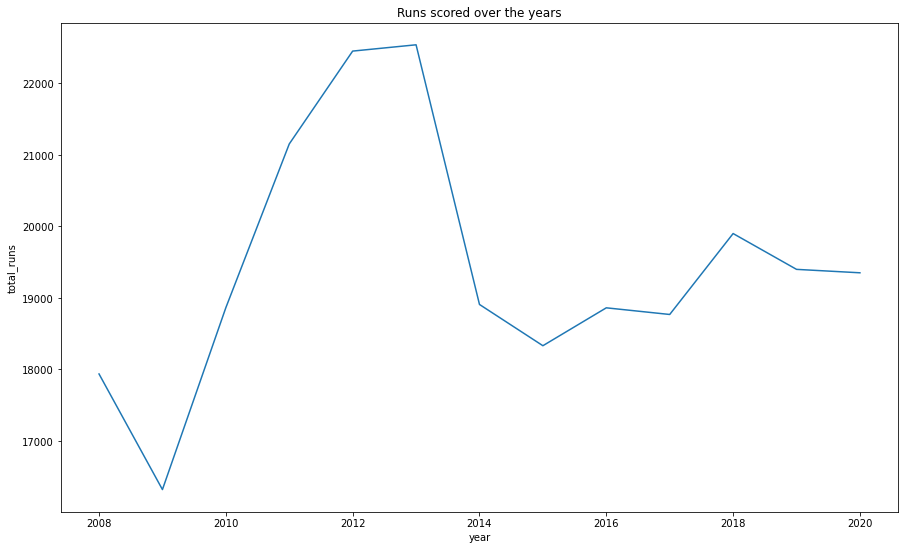

In [12]:
plt.figure(figsize=(15,9))
sns.lineplot(data=runs_by_years, x='year', y='total_runs')
plt.title('Runs scored over the years')
plt.show()

# Preferred toss decision

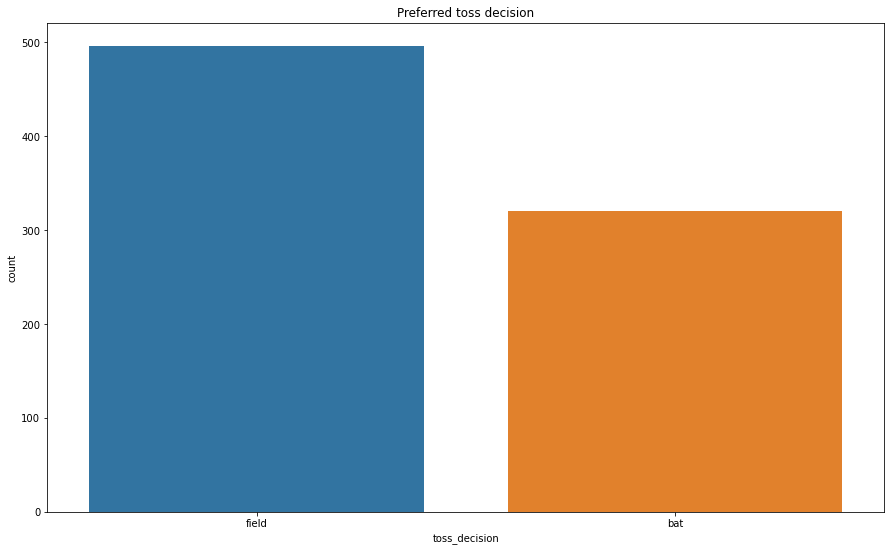

In [13]:
plt.figure(figsize=(15,9))
sns.countplot(data=matches, x='toss_decision')
plt.title('Preferred toss decision')
plt.show()

# Totals runs and wickets by over

In [14]:
runs_and_wickets_by_over = balls.groupby(by='over').sum()
runs_and_wickets_by_over = pd.DataFrame(runs_and_wickets_by_over[['total_runs', 'is_wicket']])
runs_and_wickets_by_over.reset_index(inplace=True)

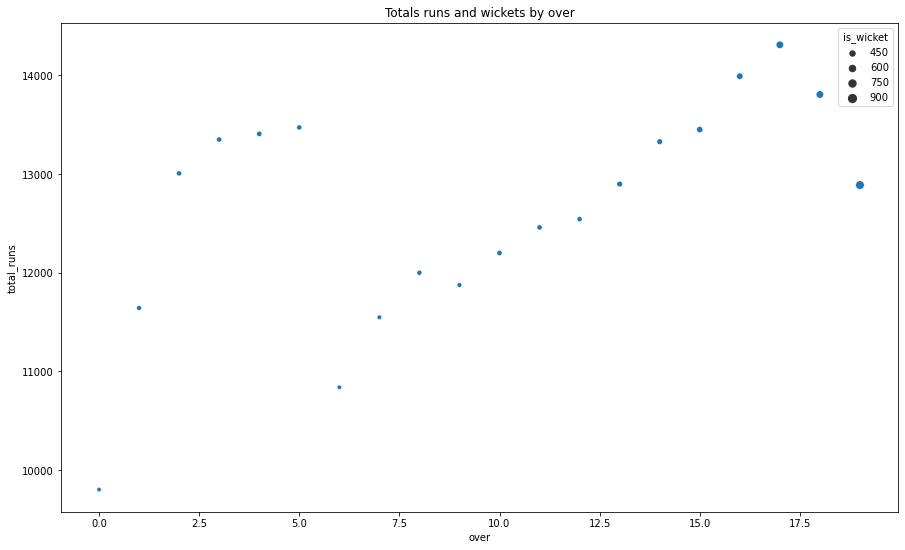

In [15]:
plt.figure(figsize=(15,9))
sns.scatterplot(data=runs_and_wickets_by_over, x='over', y='total_runs', size='is_wicket')
plt.title('Totals runs and wickets by over')
plt.show()

# Runs distribution over wise

In [16]:
balls = pd.read_csv('/kaggle/input/ipl-complete-dataset-20082020/IPL Ball-by-Ball 2008-2020.csv')
runs_overs = balls[['total_runs', 'over']]
runs_overs

,total_runs,over
0,1,6
1,1,6
2,0,7
3,1,7
4,1,7
...,...,...
193463,0,12
193464,1,12
193465,1,13
193466,1,13


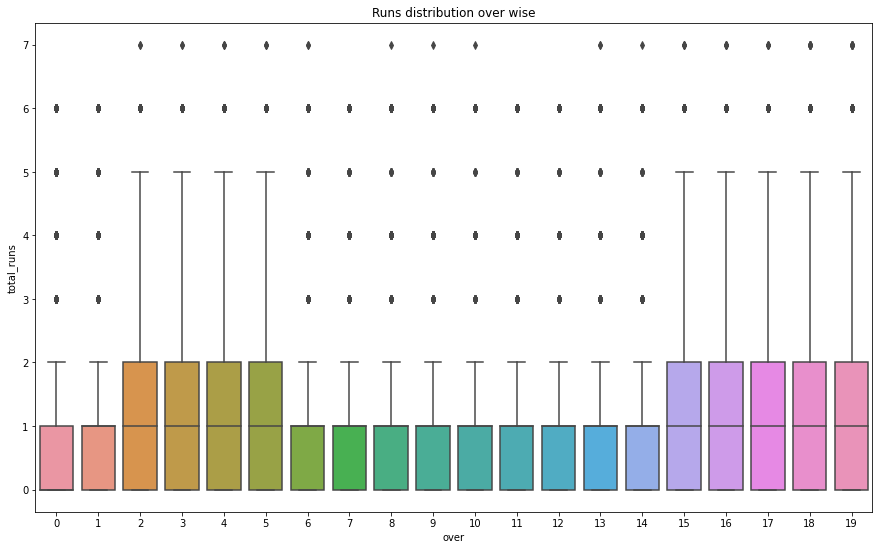

In [17]:
plt.figure(figsize=(15,9))
sns.boxplot(data=balls, x='over', y='total_runs')
plt.title('Runs distribution over wise')
plt.show()

# Runs distribution match wise

In [18]:
runs_by_match = balls.groupby(by='id').sum()
runs_by_match = pd.DataFrame(runs_by_match['total_runs'])
runs_by_match.reset_index(inplace=True)
runs_by_match

,id,total_runs
0,335982,304
1,335983,447
2,335984,261
3,335985,331
4,335986,222
...,...,...
811,1216547,402
812,1237177,343
813,1237178,263
814,1237180,361


In [19]:
print(sns.__version__)

0.11.0


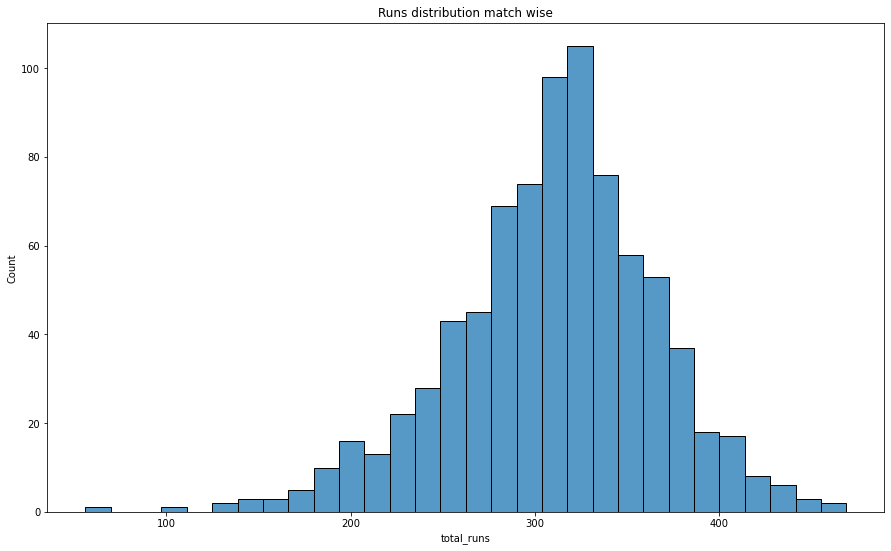

In [20]:
plt.figure(figsize=(15,9))
sns.histplot(runs_by_match['total_runs'])
plt.title('Runs distribution match wise')
plt.show()

In [21]:
data = pd.merge(left=matches, right=balls, on='id', how='right')
data['date'] = pd.to_datetime(data['date'])
data['year'] = pd.DatetimeIndex(data['date']).year

runs_by_match_and_year = data.groupby(by=['id','year']).sum()
runs_by_match_and_year = pd.DataFrame(runs_by_match_and_year[['total_runs']])
runs_by_match_and_year.reset_index(inplace=True)
runs_by_match_and_year

,id,year,total_runs
0,335982,2008,304
1,335983,2008,447
2,335984,2008,261
3,335985,2008,331
4,335986,2008,222
...,...,...,...
811,1216547,2020,402
812,1237177,2020,343
813,1237178,2020,263
814,1237180,2020,361


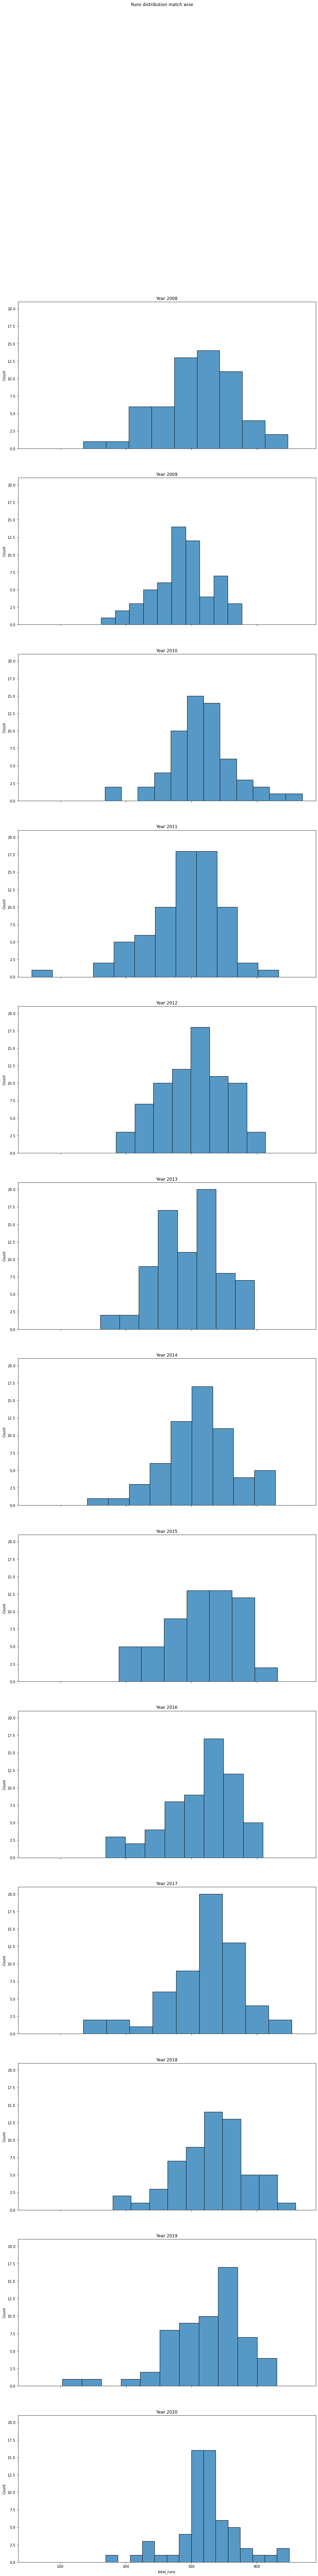

In [22]:
f, axes = plt.subplots(13, 1, sharex='all', sharey='all',figsize=(15,117))
f.suptitle("Runs distribution match wise")
sns.histplot(x=runs_by_match_and_year[runs_by_match_and_year['year']==2008]['total_runs'], ax=axes[0]).set_title('Year 2008')
sns.histplot(x=runs_by_match_and_year[runs_by_match_and_year['year']==2009]['total_runs'], ax=axes[1]).set_title('Year 2009')
sns.histplot(x=runs_by_match_and_year[runs_by_match_and_year['year']==2010]['total_runs'], ax=axes[2]).set_title('Year 2010')
sns.histplot(x=runs_by_match_and_year[runs_by_match_and_year['year']==2011]['total_runs'], ax=axes[3]).set_title('Year 2011')
sns.histplot(x=runs_by_match_and_year[runs_by_match_and_year['year']==2012]['total_runs'], ax=axes[4]).set_title('Year 2012')
sns.histplot(x=runs_by_match_and_year[runs_by_match_and_year['year']==2013]['total_runs'], ax=axes[5]).set_title('Year 2013')
sns.histplot(x=runs_by_match_and_year[runs_by_match_and_year['year']==2014]['total_runs'], ax=axes[6]).set_title('Year 2014')
sns.histplot(x=runs_by_match_and_year[runs_by_match_and_year['year']==2015]['total_runs'], ax=axes[7]).set_title('Year 2015')
sns.histplot(x=runs_by_match_and_year[runs_by_match_and_year['year']==2016]['total_runs'], ax=axes[8]).set_title('Year 2016')
sns.histplot(x=runs_by_match_and_year[runs_by_match_and_year['year']==2017]['total_runs'], ax=axes[9]).set_title('Year 2017')
sns.histplot(x=runs_by_match_and_year[runs_by_match_and_year['year']==2018]['total_runs'], ax=axes[10]).set_title('Year 2018')
sns.histplot(x=runs_by_match_and_year[runs_by_match_and_year['year']==2019]['total_runs'], ax=axes[11]).set_title('Year 2019')
sns.histplot(x=runs_by_match_and_year[runs_by_match_and_year['year']==2020]['total_runs'], ax=axes[12]).set_title('Year 2020')
plt.show()

# Runs balls wise distributions

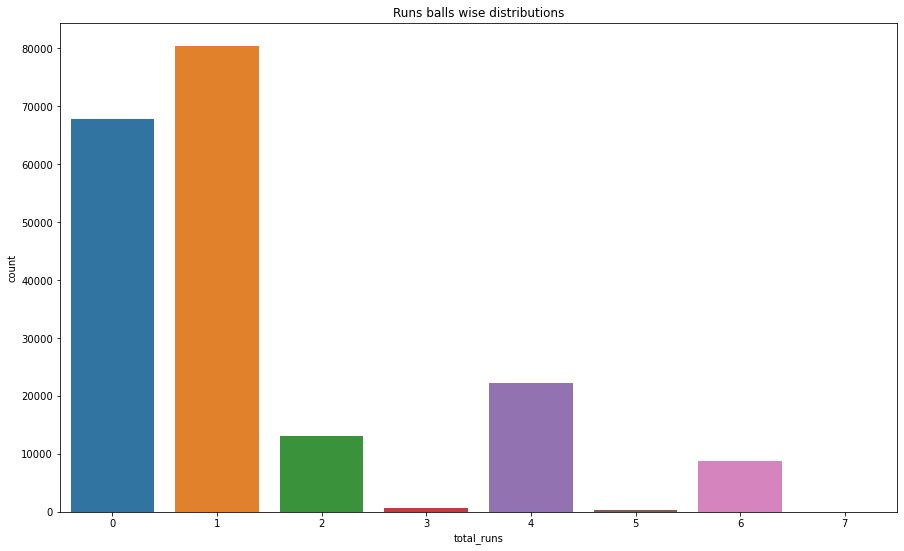

In [23]:
plt.figure(figsize=(15,9))
sns.countplot(data=balls, x='total_runs')
plt.title('Runs balls wise distributions')
plt.show()

# Runs by ball of the over

In [24]:
runs_by_ball_of_overs = balls.groupby(by=['ball', 'over']).sum()
runs_by_ball_of_overs = pd.DataFrame(runs_by_ball_of_overs[['total_runs']])
runs_by_ball_of_overs.reset_index(inplace=True)
runs_by_ball_of_overs

,ball,over,total_runs
0,1,0,1209
1,1,1,1698
2,1,2,2027
3,1,3,2003
4,1,4,2020
...,...,...,...
175,9,15,0
176,9,16,9
177,9,17,11
178,9,18,24


In [25]:
runs_by_ball_of_overs = runs_by_ball_of_overs.pivot(index='ball', columns='over', values='total_runs')

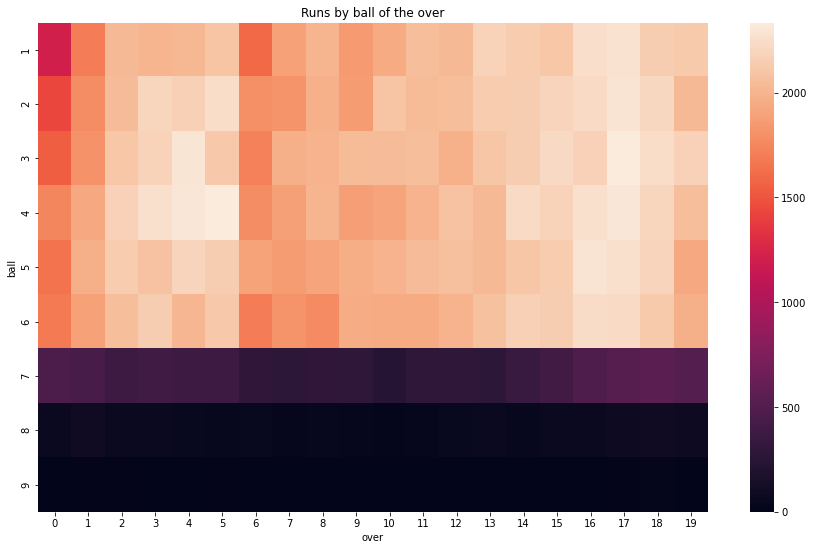

In [26]:
plt.figure(figsize=(15,9))
sns.heatmap(runs_by_ball_of_overs)
plt.title('Runs by ball of the over')
plt.show()

# How are the players being dismissed?

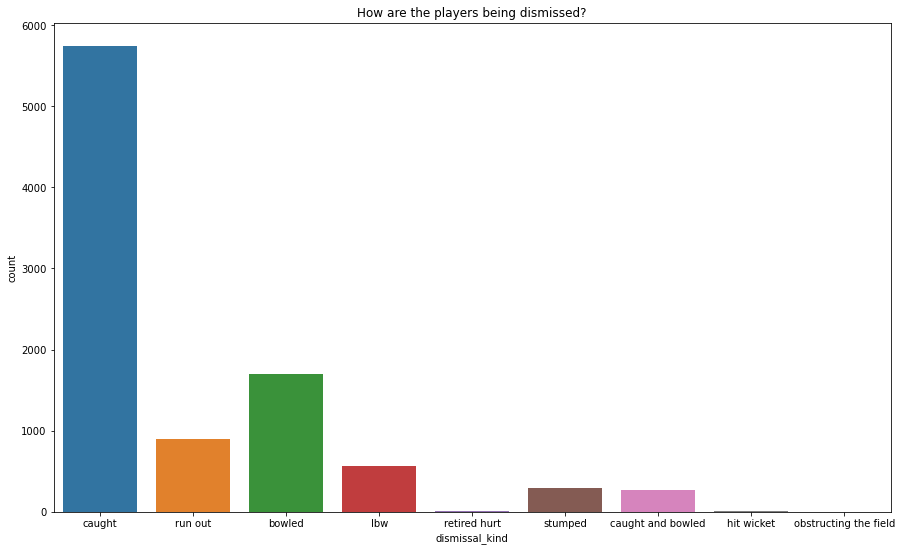

In [27]:
plt.figure(figsize=(15,9))
sns.countplot(data=balls, x='dismissal_kind')
plt.title('How are the players being dismissed?')
plt.show()

# Which bowler led to most dismissals?

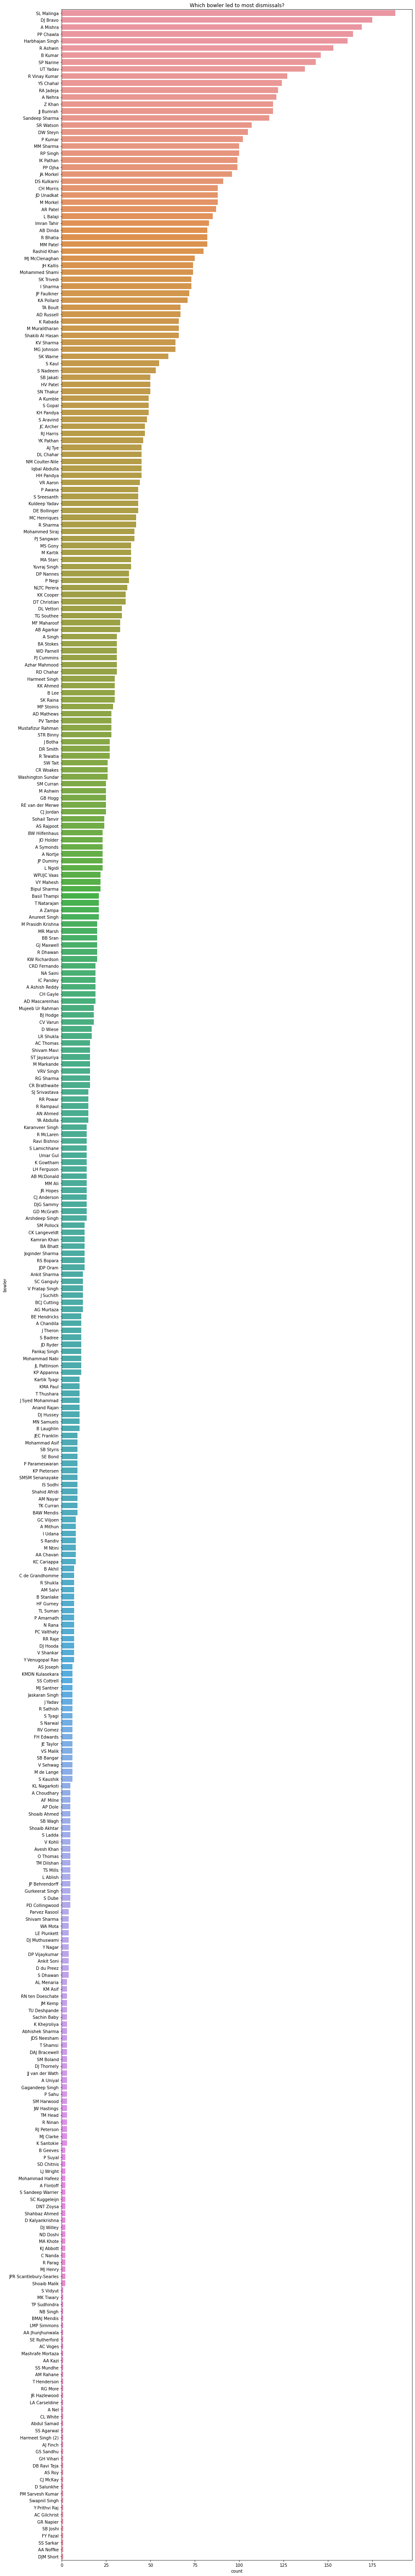

In [28]:
balls['dismissal_kind'].fillna('Not a wicket', inplace=True)
plt.figure(figsize=(15,112))
sns.countplot(y=balls[balls['dismissal_kind'] != 'Not a wicket']['bowler'],
              order=balls[balls['dismissal_kind'] != 'Not a wicket']['bowler'].value_counts().index)
plt.title('Which bowler led to most dismissals?')
plt.show()